# Temperature Causal Analysis (No question_id) — CausalML Edition

This notebook replicates the causal analysis from `evaluate_causality_analysis_no_question_id.ipynb` and
replaces all in-house estimators with **official CausalML APIs**.

## CausalML APIs used

| Category | CausalML API |
|---|---|
| Propensity estimation | `GradientBoostedPropensityModel` |
| S-Learner ATE | `BaseSLearner` |
| T-Learner ATE | `BaseTLearner` |
| X-Learner ATE | `BaseXLearner` |
| R-Learner ATE | `BaseRLearner` |
| DR-Learner ATE | `BaseDRLearner` |
| CATE / Subgroup | `CausalTreeRegressor` |
| Ranking metrics | `auuc_score`, `qini_score` |
| Attribution | SHAP on fitted CausalML model internals |

## Design choices (unchanged from baseline)

- Primary treatment: `high_temperature = 1[temperature >= 1.5]`, compared against `low_temperature = 1[temperature < 1.5]`.
- Primary estimand: ATE of moving from the low-temperature regime to the high-temperature regime.
- Adjustment set / confounders: `judge_type`, `prompt_variant`, `model` (no `question_id`).
- Moderators: `judge_type`, `prompt_variant`, `model`.
- Robustness: placebo permutation (T-Learner), approximate E-value, SHAP stability via bootstrap.


In [1]:
from __future__ import annotations

from pathlib import Path
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from graphviz import Digraph
from IPython.display import Markdown, display
from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.model_selection import KFold

# CausalML official APIs
from causalml.inference.meta import (
    BaseSLearner,
    BaseTLearner,
    BaseXLearner,
    BaseRLearner,
    BaseDRLearner,
)
from causalml.propensity import GradientBoostedPropensityModel, ElasticNetPropensityModel
from causalml.inference.tree import CausalTreeRegressor
from causalml.metrics import auuc_score, qini_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
np.random.seed(42)

DATA_DIR = Path("output/result_without_rep_id")
FIG_DIR = Path("output/causal_analysis_causalml")
FIG_DIR.mkdir(parents=True, exist_ok=True)

METRIC_COLUMNS = ["Agreement (µ)", "Consistency (µ)", "Error Rate (µ)"]
TREATMENT_SOURCE = "temperature"
TREATMENT_COL = "high_temperature"
TREATMENT_LABEL = "High temperature (>= 1.5) vs Low temperature (< 1.5)"
COVARIATE_COLUMNS = ["question_id", "judge_type", "prompt_variant", "model"]
MODERATOR_COLUMNS = ["judge_type", "prompt_variant", "model"]

data_paths = {
    path.stem.replace("metrics_by_question_judge_prompt_temp_", ""): path
    for path in sorted(DATA_DIR.glob("metrics_by_question_judge_prompt_temp_*.jsonl"))
}
MODEL_NAMES = list(data_paths)

if not MODEL_NAMES:
    raise FileNotFoundError(f"No model files found under {DATA_DIR}")

dfs = []
for model_name, path in data_paths.items():
    if "Thinking" not in model_name and "Llama" not in model_name:
        df = pd.read_json(path, lines=True)
        df["model"] = model_name
        dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)
combined_df[TREATMENT_SOURCE] = pd.to_numeric(combined_df[TREATMENT_SOURCE], errors="coerce")
combined_df[METRIC_COLUMNS] = combined_df[METRIC_COLUMNS].apply(pd.to_numeric, errors="coerce")
combined_df["question_id"] = combined_df["question_id"].astype(str)
combined_df[TREATMENT_COL] = (combined_df[TREATMENT_SOURCE] >= 1.5).astype(int)
combined_df["temperature_bucket"] = pd.Categorical(
    np.where(combined_df[TREATMENT_COL].eq(1), "high (>=1.5)", "low (<1.5)"),
    categories=["low (<1.5)", "high (>=1.5)"],
    ordered=True,
)

for col in COVARIATE_COLUMNS:
    combined_df[col] = combined_df[col].astype("category")

ANALYSIS_COLUMNS = [TREATMENT_SOURCE, TREATMENT_COL] + COVARIATE_COLUMNS + METRIC_COLUMNS


# ── Helpers shared with later cells ──────────────────────────────────────────

def standardized_mean_difference_binary(x: pd.Series, t: pd.Series) -> float:
    x = pd.to_numeric(x, errors="coerce").fillna(0.0)
    t = pd.to_numeric(t, errors="coerce").fillna(0).astype(int)
    treated = x[t.eq(1)]
    control = x[t.eq(0)]
    if len(treated) == 0 or len(control) == 0:
        return np.nan
    m1, m0 = float(treated.mean()), float(control.mean())
    v1 = float(treated.var(ddof=1)) if len(treated) > 1 else 0.0
    v0 = float(control.var(ddof=1)) if len(control) > 1 else 0.0
    pooled = math.sqrt(max((v1 + v0) / 2.0, 1e-12))
    return abs(m1 - m0) / pooled if pooled > 0 else 0.0


def _feature_family(name: str) -> str:
    for family in COVARIATE_COLUMNS:
        if name == family or name.startswith(f"{family}_"):
            return family
    return "other"


def compute_balance_table(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    dummies = pd.get_dummies(df[COVARIATE_COLUMNS], drop_first=False, dtype=float)
    treat = df[TREATMENT_COL].astype(int)
    detail_rows = [
        {"feature": col, "family": _feature_family(col),
         "abs_smd": standardized_mean_difference_binary(dummies[col], treat)}
        for col in dummies.columns
    ]
    balance_detail = pd.DataFrame(detail_rows).sort_values("abs_smd", ascending=False).reset_index(drop=True)
    balance_summary = (
        balance_detail.groupby("family", as_index=False)["abs_smd"]
        .agg(["mean", "max", "median"])
        .reset_index()
        .rename(columns={"mean": "mean_abs_smd", "max": "max_abs_smd", "median": "median_abs_smd"})
        .sort_values("max_abs_smd", ascending=False)
        .reset_index(drop=True)
    )
    return balance_summary, balance_detail


def build_dag() -> Digraph:
    dag = Digraph()
    dag.attr(rankdir="LR")
    dag.node("J", "judge_type", shape="box")
    dag.node("P", "prompt_variant", shape="box")
    dag.node("M", "model", shape="box")
    dag.node("T", "temperature", shape="ellipse", style="filled", fillcolor="lightblue")
    dag.node("A", "Agreement (µ)", shape="ellipse")
    dag.node("C", "Consistency (µ)", shape="ellipse")
    dag.node("E", "Error Rate (µ)", shape="ellipse")
    dag.node("U", "latent prompt / parsing complexity", shape="diamond", style="dashed")
    for parent in ["J", "P", "M"]:
        dag.edge(parent, "T")
        dag.edge(parent, "A")
        dag.edge(parent, "C")
        dag.edge(parent, "E")
    dag.edge("T", "A")
    dag.edge("T", "C")
    dag.edge("T", "E")
    dag.edge("U", "A", style="dashed")
    dag.edge("U", "C", style="dashed")
    dag.edge("U", "E", style="dashed")
    return dag


def approximate_e_value(y: pd.Series, ate: float) -> dict:
    y_clean = pd.to_numeric(y, errors="coerce").dropna()
    sd = float(y_clean.std(ddof=1)) if len(y_clean) > 1 else np.nan
    if not np.isfinite(sd) or sd == 0:
        return {"Cohen's d": np.nan, "Approx RR": np.nan, "E-value": np.nan}
    d_value = ate / sd
    rr_approx = math.exp(0.91 * abs(d_value))
    e_value = rr_approx + math.sqrt(rr_approx * (rr_approx - 1.0)) if rr_approx > 1.0 else 1.0
    return {"Cohen's d": float(d_value), "Approx RR": float(rr_approx), "E-value": float(e_value)}


def grouped_shap_importance(model, data: pd.DataFrame, max_rows: int = 3000,
                             random_state: int = 42) -> pd.DataFrame:
    sample = data.sample(min(len(data), max_rows), random_state=random_state).copy()
    explainer = shap.TreeExplainer(model)
    explanation = explainer(sample)
    sv = np.asarray(explanation.values)
    if sv.ndim == 3:
        sv = sv[:, :, -1]
    abs_shap = pd.DataFrame(np.abs(sv), columns=sample.columns)
    return (
        pd.DataFrame({"feature": sample.columns, "mean_abs_shap": abs_shap.mean(axis=0).values})
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    ), sample


print(f"Loaded {len(combined_df):,} rows from {len(MODEL_NAMES)} model files.")
print("Models:", MODEL_NAMES)
print("Temperature support:", sorted(combined_df[TREATMENT_SOURCE].dropna().unique().tolist()))


Failed to import duecredit due to No module named 'duecredit'


Loaded 54,000 rows from 5 model files.
Models: ['Llama-3.1-8B-Instruct', 'Qwen3-30B-A3B-Instruct-2507', 'Qwen3-Next-80B-A3B-Instruct-FP8', 'Qwen3-Next-80B-A3B-Thinking-FP8', 'gemma-3-27b-it']
Temperature support: [0.01, 0.5, 1.0, 1.5, 2.0, 3.0]


In [2]:
# ── No-question_id config override ──────────────────────────────────────────
COVARIATE_COLUMNS[:] = ["judge_type", "prompt_variant", "model"]
MODERATOR_COLUMNS[:] = ["judge_type", "prompt_variant", "model"]

FIG_DIR = Path("output/causal_analysis_causalml")
FIG_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_COLUMNS = [TREATMENT_SOURCE, TREATMENT_COL] + COVARIATE_COLUMNS + METRIC_COLUMNS

for col in COVARIATE_COLUMNS:
    combined_df[col] = combined_df[col].astype("category")

COLUMN_MAP = pd.DataFrame(
    [
        {"Role": "Treatment", "Variable": TREATMENT_SOURCE, "Description": "Sampling temperature of the judge model."},
        {"Role": "Binary treatment", "Variable": TREATMENT_COL, "Description": TREATMENT_LABEL},
        {"Role": "Outcome", "Variable": "Agreement (µ)", "Description": "Average agreement within each grouped unit."},
        {"Role": "Outcome", "Variable": "Consistency (µ)", "Description": "Average consistency within each grouped unit."},
        {"Role": "Outcome", "Variable": "Error Rate (µ)", "Description": "Average parse / format error rate within each grouped unit."},
        {"Role": "Confounder / Moderator", "Variable": "judge_type", "Description": "Pairwise / single-answer / reference-guided judgment mode."},
        {"Role": "Confounder / Moderator", "Variable": "prompt_variant", "Description": "Prompt strategy such as baseline or chain-of-thought."},
        {"Role": "Confounder / Moderator", "Variable": "model", "Description": "Judge model identity."},
    ]
)

# ── Feature matrix for CausalML (label-encoded integers, no category dtype) ──
analysis_df = combined_df.dropna(subset=COVARIATE_COLUMNS + METRIC_COLUMNS).copy()

X_causal = analysis_df[COVARIATE_COLUMNS].copy()
for col in X_causal.select_dtypes("category").columns:
    X_causal[col] = X_causal[col].cat.codes.astype(int)

T_arr = analysis_df[TREATMENT_COL].astype(int).to_numpy()
X_arr_np = X_causal.to_numpy(dtype=float)  # numpy array for CausalTreeRegressor

print("No-question_id config applied.")
print(f"analysis_df rows: {len(analysis_df):,}")
print("Covariates:", COVARIATE_COLUMNS)
print("FIG_DIR:", FIG_DIR)
print("X_causal dtypes:", X_causal.dtypes.to_dict())


No-question_id config applied.
analysis_df rows: 53,807
Covariates: ['judge_type', 'prompt_variant', 'model']
FIG_DIR: output/causal_analysis_causalml
X_causal dtypes: {'judge_type': dtype('int64'), 'prompt_variant': dtype('int64'), 'model': dtype('int64')}


,Role,Variable,Description
0,Treatment,temperature,Sampling temperature of the judge model.
1,Binary treatment,high_temperature,High temperature (>= 1.5) vs Low temperature (...
2,Outcome,Agreement (µ),Average agreement within each grouped unit.
3,Outcome,Consistency (µ),Average consistency within each grouped unit.
4,Outcome,Error Rate (µ),Average parse / format error rate within each ...
5,Confounder / Moderator,judge_type,Pairwise / single-answer / reference-guided ju...
6,Confounder / Moderator,prompt_variant,Prompt strategy such as baseline or chain-of-t...
7,Confounder / Moderator,model,Judge model identity.


,temperature,high_temperature,judge_type,prompt_variant,model,Agreement (µ),Consistency (µ),Error Rate (µ)
0,0.01,0,pairwise,baseline,Qwen3-30B-A3B-Instruct-2507,1.0,1.0,0.0
1,0.50,0,pairwise,baseline,Qwen3-30B-A3B-Instruct-2507,1.0,1.0,0.0
2,1.00,0,pairwise,baseline,Qwen3-30B-A3B-Instruct-2507,1.0,1.0,0.0
3,1.50,1,pairwise,baseline,Qwen3-30B-A3B-Instruct-2507,1.0,1.0,0.0
4,2.00,1,pairwise,baseline,Qwen3-30B-A3B-Instruct-2507,1.0,1.0,0.0


Agreement (µ)                   Consistency (µ)                    \
                     mean     std  min  max            mean     std  min  max   
temperature                                                                     
0.01               0.5591  0.4775  0.0  1.0          0.9454  0.1534  0.0  1.0   
0.50               0.5565  0.4663  0.0  1.0          0.9109  0.1919  0.0  1.0   
1.00               0.5558  0.4547  0.0  1.0          0.8767  0.2217  0.0  1.0   
1.50               0.5535  0.4406  0.0  1.0          0.8394  0.2434  0.0  1.0   
2.00               0.5475  0.4254  0.0  1.0          0.7982  0.2587  0.0  1.0   
3.00               0.5184  0.3884  0.0  1.0          0.6925  0.2899  0.0  1.0   

            Error Rate (µ)                    
                      mean     std  min  max  
temperature                                   
0.01                0.0156  0.0968  0.0  1.0  
0.50                0.0184  0.0956  0.0  1.0  
1.00                0.0229  0.0971  0.0  1.0  
1.50                0.0309  0.1023  0.0  1.0  
2.00                0.0506  0.1253  0.0  1.0  
3.00                0.1249  0.1939  0.0  1.0

,rows
temperature_bucket,
low (<1.5),27000
high (>=1.5),27000


Balance summary by covariate family (absolute SMD):


,index,family,mean_abs_smd,max_abs_smd,median_abs_smd
0,0,judge_type,0.0,0.0,0.0
1,1,model,0.0,0.0,0.0
2,2,prompt_variant,0.0,0.0,0.0


Largest individual imbalances:


,feature,family,abs_smd
0,judge_type_pairwise,judge_type,0.0
1,judge_type_reference_guided,judge_type,0.0
2,judge_type_single_answer,judge_type,0.0
3,prompt_variant_baseline,prompt_variant,0.0
4,prompt_variant_cot,prompt_variant,0.0
5,model_Qwen3-30B-A3B-Instruct-2507,model,0.0
6,model_Qwen3-Next-80B-A3B-Instruct-FP8,model,0.0
7,model_gemma-3-27b-it,model,0.0


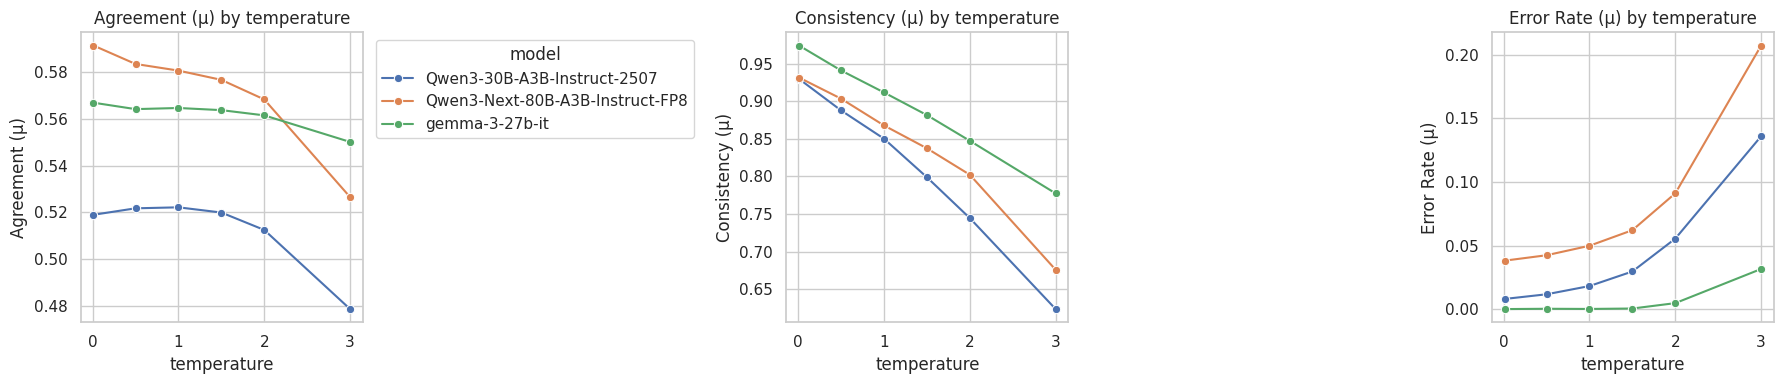

Saved: output/causal_analysis_causalml/temperature_metric_trends_by_model.png


In [3]:
display(COLUMN_MAP)

display(combined_df[ANALYSIS_COLUMNS].head())

descriptive_stats = (
    combined_df.groupby(TREATMENT_SOURCE, observed=True)[METRIC_COLUMNS]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)
display(descriptive_stats)

treatment_counts = combined_df["temperature_bucket"].value_counts().rename_axis("temperature_bucket").to_frame("rows")
display(treatment_counts)

balance_summary, balance_detail = compute_balance_table(combined_df)
print("Balance summary by covariate family (absolute SMD):")
display(balance_summary.round(4))

print("Largest individual imbalances:")
display(balance_detail.head(10).round(4))

temp_by_model = (
    combined_df.groupby([TREATMENT_SOURCE, "model"], observed=True)[METRIC_COLUMNS]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
for ax, outcome_col in zip(axes, METRIC_COLUMNS):
    sns.lineplot(
        data=temp_by_model,
        x=TREATMENT_SOURCE,
        y=outcome_col,
        hue="model",
        marker="o",
        ax=ax,
    )
    ax.set_title(f"{outcome_col} by temperature")
    ax.set_xlabel("temperature")
    ax.set_ylabel(outcome_col)
    if ax is not axes[0]:
        ax.get_legend().remove()

axes[0].legend(title="model", bbox_to_anchor=(1.02, 1.0), loc="upper left")
plt.tight_layout()
trend_path = FIG_DIR / "temperature_metric_trends_by_model.png"
fig.savefig(trend_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", trend_path)

## 1. Causal Graph

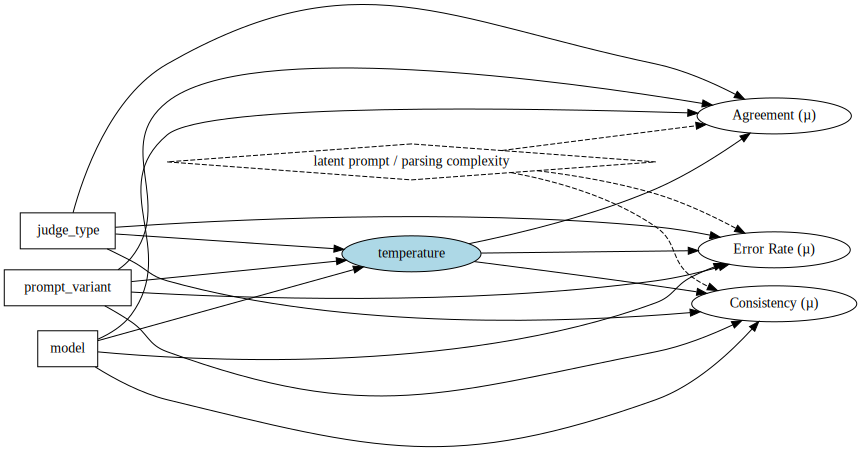

Saved: output/causal_analysis_causalml/temperature_causal_dag.png


## 2. Propensity Score Estimation
Using CausalML's `GradientBoostedPropensityModel` to estimate P(T=1 | X).

Propensity scores — min: 0.4977  max: 0.5063  mean: 0.5003


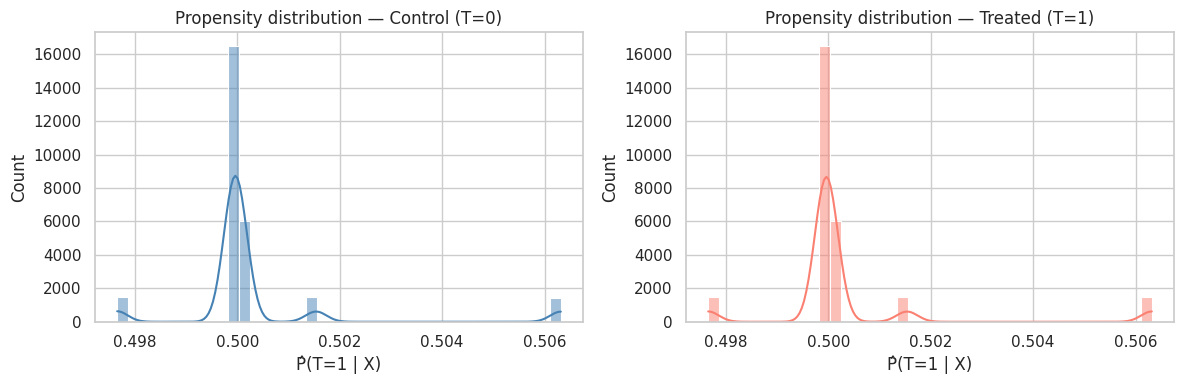

Saved: output/causal_analysis_causalml/propensity_score_distribution.png


,Group,n,PS mean,PS std,PS min,PS max
0,Control (T=0),26889,0.5003,0.0016,0.4977,0.5063
1,Treated (T=1),26918,0.5003,0.0016,0.4977,0.5063


In [4]:
display(Markdown("## 1. Causal Graph"))
dag = build_dag()
display(dag)
try:
    dag_path = FIG_DIR / "temperature_causal_dag"
    dag.render(dag_path.as_posix(), format="png", cleanup=True)
    print("Saved:", dag_path.with_suffix(".png"))
except Exception as exc:
    print("DAG render skipped:", repr(exc))

# ── CausalML: Propensity estimation ─────────────────────────────────────────
display(Markdown(
    "## 2. Propensity Score Estimation\n"
    "Using CausalML's `GradientBoostedPropensityModel` to estimate P(T=1 | X)."
))

ps_model = GradientBoostedPropensityModel(random_state=42)
ps_arr = ps_model.fit_predict(X=X_causal, y=T_arr)
print(f"Propensity scores — min: {ps_arr.min():.4f}  max: {ps_arr.max():.4f}  mean: {ps_arr.mean():.4f}")

# Overlap / positivity plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (label, mask, color) in zip(
    axes,
    [("Control (T=0)", T_arr == 0, "steelblue"), ("Treated (T=1)", T_arr == 1, "salmon")],
):
    sns.histplot(ps_arr[mask], bins=40, ax=ax, color=color, kde=True)
    ax.set_title(f"Propensity distribution — {label}")
    ax.set_xlabel("P̂(T=1 | X)")
    ax.set_ylabel("Count")
plt.tight_layout()
ps_fig_path = FIG_DIR / "propensity_score_distribution.png"
fig.savefig(ps_fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", ps_fig_path)

# Overlap summary
ps_control = ps_arr[T_arr == 0]
ps_treated = ps_arr[T_arr == 1]
overlap_df = pd.DataFrame({
    "Group": ["Control (T=0)", "Treated (T=1)"],
    "n": [int((T_arr == 0).sum()), int((T_arr == 1).sum())],
    "PS mean": [float(ps_control.mean()), float(ps_treated.mean())],
    "PS std": [float(ps_control.std()), float(ps_treated.std())],
    "PS min": [float(ps_control.min()), float(ps_treated.min())],
    "PS max": [float(ps_control.max()), float(ps_treated.max())],
})
display(overlap_df.round(4))


## 3. ATE Estimation: Meta-Learner Comparison
Five CausalML meta-learners are fitted for each outcome. To keep runtime practical, this notebook uses a lighter LightGBM base learner while preserving the same causal estimands and comparison structure.

[S-Learner] fitting for Agreement (µ) ... ATE = -0.0166
[T-Learner] fitting for Agreement (µ) ... ATE = -0.0171
[X-Learner] fitting for Agreement (µ) ... ATE = -0.0172
[R-Learner] fitting for Agreement (µ) ... 

/home/snt/projects_lujun/LLMJudgeTempCausal/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/snt/projects_lujun/LLMJudgeTempCausal/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/snt/projects_lujun/LLMJudgeTempCausal/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/snt/projects_lujun/LLMJudgeTempCausal/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/snt/projects_lujun/LLMJudgeTempCausal/.venv/lib/python3.11/site-packages/sklearn/u

ATE = -0.0171
[DR-Learner] fitting for Agreement (µ) ... ATE = -0.0171
[S-Learner] fitting for Consistency (µ) ... ATE = -0.1305
[T-Learner] fitting for Consistency (µ) ... ATE = -0.1342
[X-Learner] fitting for Consistency (µ) ... ATE = -0.1342
[R-Learner] fitting for Consistency (µ) ... 

/home/snt/projects_lujun/LLMJudgeTempCausal/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/snt/projects_lujun/LLMJudgeTempCausal/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/snt/projects_lujun/LLMJudgeTempCausal/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/snt/projects_lujun/LLMJudgeTempCausal/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/snt/projects_lujun/LLMJudgeTempCausal/.venv/lib/python3.11/site-packages/sklearn/u

ATE = -0.1343
[DR-Learner] fitting for Consistency (µ) ... ATE = -0.1342
[S-Learner] fitting for Error Rate (µ) ... ATE = 0.0495
[T-Learner] fitting for Error Rate (µ) ... ATE = 0.0509
[X-Learner] fitting for Error Rate (µ) ... ATE = 0.0509
[R-Learner] fitting for Error Rate (µ) ... 

/home/snt/projects_lujun/LLMJudgeTempCausal/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/snt/projects_lujun/LLMJudgeTempCausal/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/snt/projects_lujun/LLMJudgeTempCausal/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/snt/projects_lujun/LLMJudgeTempCausal/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/snt/projects_lujun/LLMJudgeTempCausal/.venv/lib/python3.11/site-packages/sklearn/u

ATE = 0.0509
[DR-Learner] fitting for Error Rate (µ) ... ATE = 0.0509


,Outcome,Method,ATE,CI Low,CI High,ATE (95% CI)
0,Agreement (µ),S-Learner,-0.016619,-0.016791,-0.016446,"-0.0166 [-0.0168, -0.0164]"
1,Agreement (µ),T-Learner,-0.017104,-0.017273,-0.016935,"-0.0171 [-0.0173, -0.0169]"
2,Agreement (µ),X-Learner,-0.017160,-0.017330,-0.016990,"-0.0172 [-0.0173, -0.0170]"
3,Agreement (µ),R-Learner,-0.017102,-0.017267,-0.016937,"-0.0171 [-0.0173, -0.0169]"
4,Agreement (µ),DR-Learner,-0.017149,-0.017318,-0.016981,"-0.0171 [-0.0173, -0.0170]"
5,Consistency (µ),S-Learner,-0.130508,-0.130815,-0.130200,"-0.1305 [-0.1308, -0.1302]"
6,Consistency (µ),T-Learner,-0.134215,-0.134513,-0.133916,"-0.1342 [-0.1345, -0.1339]"
7,Consistency (µ),X-Learner,-0.134222,-0.134548,-0.133897,"-0.1342 [-0.1345, -0.1339]"
8,Consistency (µ),R-Learner,-0.134269,-0.134554,-0.133985,"-0.1343 [-0.1346, -0.1340]"
9,Consistency (µ),DR-Learner,-0.134243,-0.134537,-0.133949,"-0.1342 [-0.1345, -0.1339]"


Saved: output/causal_analysis_causalml/meta_learner_ate_comparison.csv


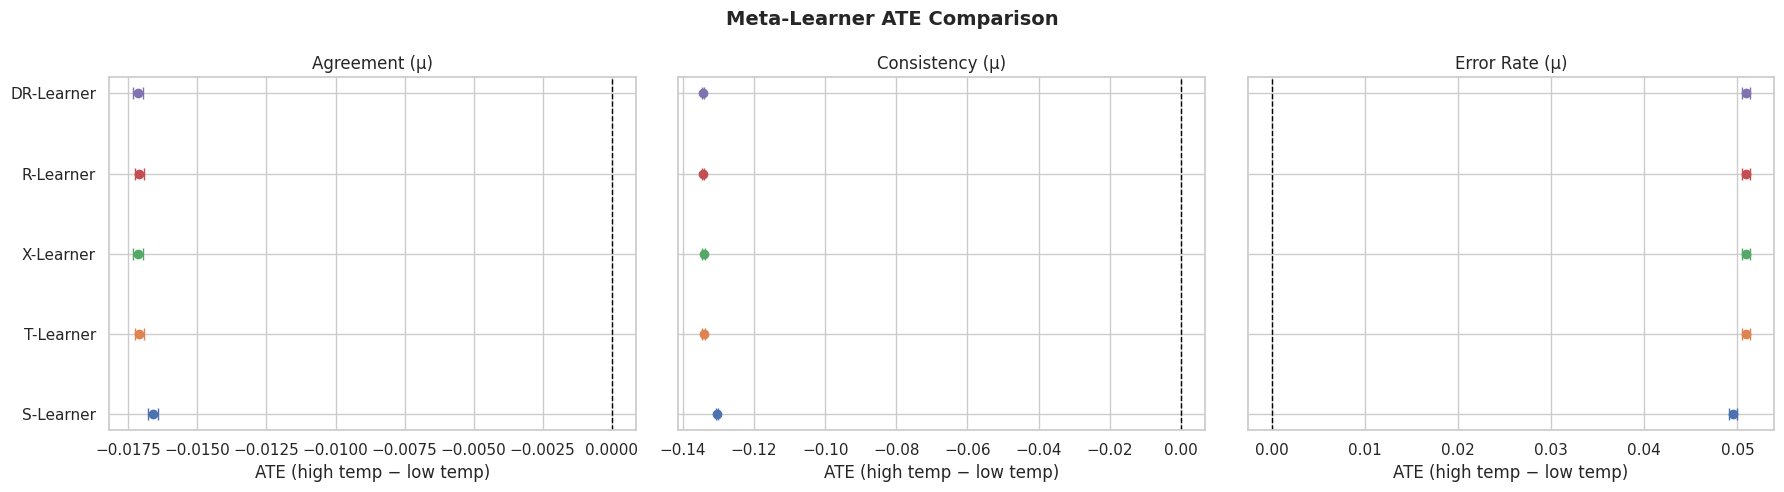

Saved: output/causal_analysis_causalml/meta_learner_ate_forest_plot.png


In [5]:
display(Markdown(
    "## 3. ATE Estimation: Meta-Learner Comparison\n"
    "Five CausalML meta-learners are fitted for each outcome. "
    "To keep runtime practical, this notebook uses a lighter LightGBM base learner "
    "while preserving the same causal estimands and comparison structure."
))

# Lightweight base learner for faster CausalML fitting.
LGBM_KWARGS = dict(
    n_estimators=60,
    learning_rate=0.08,
    num_leaves=15,
    max_depth=5,
    min_child_samples=100,
    subsample=0.8,
    colsample_bytree=0.8,
    max_bin=127,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    force_col_wise=True,
)


def make_fast_regressor(seed: int) -> LGBMRegressor:
    return LGBMRegressor(**{**LGBM_KWARGS, "random_state": seed})


def flatten_cate(te) -> np.ndarray:
    arr = np.asarray(te)
    return arr[:, 0] if arr.ndim > 1 else arr.flatten()


def cate_to_ate_ci(te) -> tuple[float, float, float]:
    te = flatten_cate(te)
    ate = float(te.mean())
    se = float(te.std(ddof=1) / np.sqrt(len(te)))
    return ate, ate - 1.96 * se, ate + 1.96 * se


LEARNER_FACTORIES = {
    "S-Learner": lambda: BaseSLearner(learner=make_fast_regressor(11), control_name=0),
    "T-Learner": lambda: BaseTLearner(learner=make_fast_regressor(21), control_name=0),
    "X-Learner": lambda: BaseXLearner(learner=make_fast_regressor(31), control_name=0),
    "R-Learner": lambda: BaseRLearner(learner=make_fast_regressor(41), control_name=0),
    "DR-Learner": lambda: BaseDRLearner(learner=make_fast_regressor(51), control_name=0),
}
NEEDS_PS = {"X-Learner", "R-Learner", "DR-Learner"}

meta_results = {}   # {outcome_col: {method: {ate, lb, ub, te, learner}}}
ate_rows = []
X_meta = X_arr_np

for outcome_col in METRIC_COLUMNS:
    Y_arr = analysis_df[outcome_col].to_numpy()
    outcome_res = {}
    for method_name, make_learner in LEARNER_FACTORIES.items():
        print(f"[{method_name}] fitting for {outcome_col} ...", end=" ")
        learner = make_learner()
        p_arg = ps_arr if method_name in NEEDS_PS else None
        te = learner.fit_predict(
            X=X_meta,
            treatment=T_arr,
            y=Y_arr,
            p=p_arg,
            verbose=False,
        )
        te_flat = flatten_cate(te)
        ate, lb, ub = cate_to_ate_ci(te_flat)
        outcome_res[method_name] = {
            "ate": ate,
            "lb": lb,
            "ub": ub,
            "te": te_flat,
            "learner": learner,
        }
        ate_rows.append(
            {
                "Outcome": outcome_col,
                "Method": method_name,
                "ATE": ate,
                "CI Low": lb,
                "CI High": ub,
                "ATE (95% CI)": f"{ate:.4f} [{lb:.4f}, {ub:.4f}]",
            }
        )
        print(f"ATE = {ate:.4f}")
    meta_results[outcome_col] = outcome_res

ate_comparison_df = pd.DataFrame(ate_rows)
display(ate_comparison_df)
ate_comparison_path = FIG_DIR / "meta_learner_ate_comparison.csv"
ate_comparison_df.to_csv(ate_comparison_path, index=False)
print("Saved:", ate_comparison_path)

# ── Forest plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
colors = ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b2"]

for ax, outcome_col in zip(axes, METRIC_COLUMNS):
    rows = ate_comparison_df[ate_comparison_df["Outcome"] == outcome_col]
    y_pos = np.arange(len(rows))
    for i, (_, row) in enumerate(rows.iterrows()):
        ax.errorbar(
            row["ATE"],
            y_pos[i],
            xerr=[[row["ATE"] - row["CI Low"]], [row["CI High"] - row["ATE"]]],
            fmt="o",
            color=colors[i % len(colors)],
            capsize=4,
            linewidth=1.5,
        )
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(rows["Method"].tolist())
    ax.set_title(f"{outcome_col}")
    ax.set_xlabel("ATE (high temp − low temp)")

fig.suptitle("Meta-Learner ATE Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
forest_path = FIG_DIR / "meta_learner_ate_forest_plot.png"
fig.savefig(forest_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", forest_path)


## 4. CATE Estimation via CausalTreeRegressor
CausalML's `CausalTreeRegressor` directly estimates heterogeneous treatment effects by recursively partitioning the covariate space.

Agreement (µ): CausalTree ATE = -0.0171
Consistency (µ): CausalTree ATE = -0.1342
Error Rate (µ): CausalTree ATE = 0.0509


,Outcome,CausalTree ATE,CATE std,CATE min,CATE max
0,Agreement (µ),-0.0171,0.0267,-0.0575,0.0679
1,Consistency (µ),-0.1342,0.0445,-0.2246,-0.0504
2,Error Rate (µ),0.0509,0.0553,0.0000,0.1596


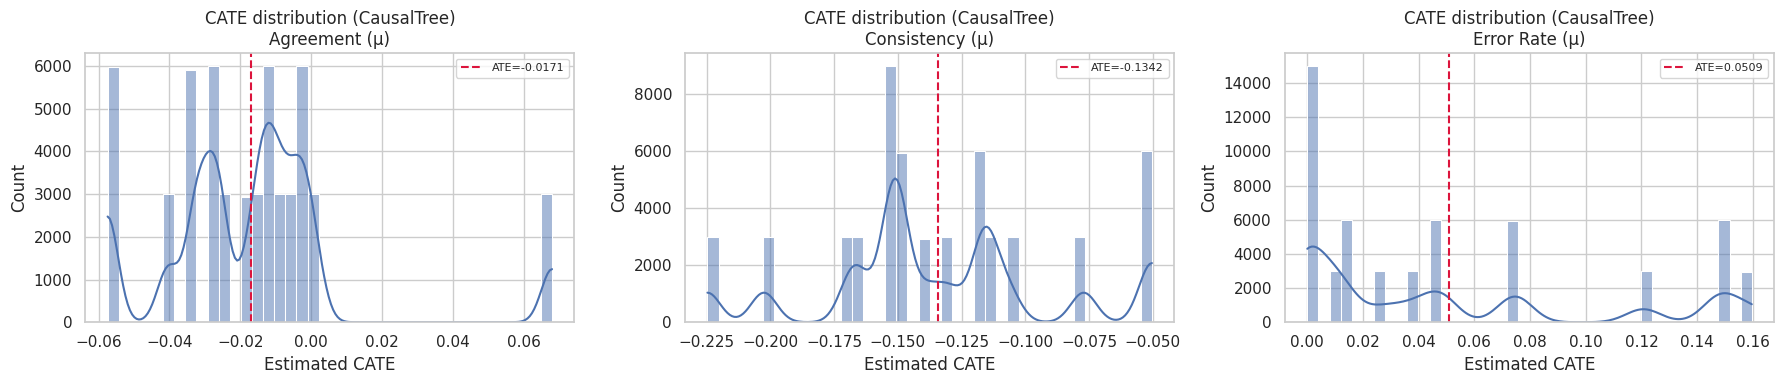

Saved: output/causal_analysis_causalml/causal_tree_cate_distributions.png


,Level,Mean CATE (CausalTree),Outcome,Moderator
1,reference_guided,-0.029819,Agreement (µ),judge_type
0,pairwise,-0.012929,Agreement (µ),judge_type
2,single_answer,-0.008523,Agreement (µ),judge_type
6,Qwen3-Next-80B-A3B-Instruct-FP8,-0.028234,Agreement (µ),model
5,Qwen3-30B-A3B-Instruct-2507,-0.016438,Agreement (µ),model
7,gemma-3-27b-it,-0.006744,Agreement (µ),model
4,cot,-0.028758,Agreement (µ),prompt_variant
3,baseline,-0.005533,Agreement (µ),prompt_variant
10,single_answer,-0.160756,Consistency (µ),judge_type
9,reference_guided,-0.133639,Consistency (µ),judge_type


Saved: output/causal_analysis_causalml/causal_tree_subgroup_cate.csv


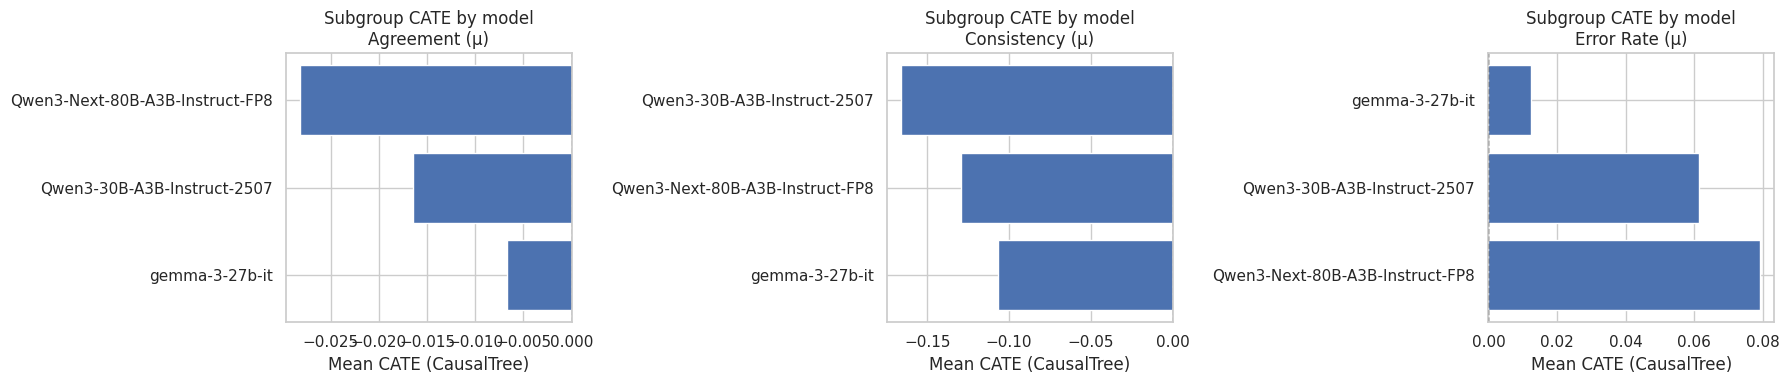

Saved: output/causal_analysis_causalml/causal_tree_subgroup_by_model.png


### AUUC and Qini Scores
CausalML expects one or more model-score columns in addition to `y` and `w`. Here we compare uplift ranking quality across all five meta-learners.

,Outcome,AUUC (S-Learner),Qini (S-Learner),AUUC (T-Learner),Qini (T-Learner),AUUC (X-Learner),Qini (X-Learner),AUUC (R-Learner),Qini (R-Learner),AUUC (DR-Learner),Qini (DR-Learner)
0,Agreement (µ),-0.1327,0.3672,-0.1628,0.3371,-0.1661,0.3338,-0.1711,0.3289,-0.1677,0.3322
1,Consistency (µ),-0.4111,0.0888,-0.4247,0.0752,-0.4138,0.0861,-0.4252,0.0748,-0.4247,0.0752
2,Error Rate (µ),0.7927,0.2931,0.7866,0.2870,0.7878,0.2883,0.7872,0.2877,0.7872,0.2877


Saved: output/causal_analysis_causalml/auuc_qini_scores.csv


In [6]:
display(Markdown(
    "## 4. CATE Estimation via CausalTreeRegressor\n"
    "CausalML's `CausalTreeRegressor` directly estimates heterogeneous treatment effects "
    "by recursively partitioning the covariate space."
))

# ── Fit CausalTreeRegressor for each outcome ──────────────────────────────────
ctr_results = {}
cate_rows = []

for outcome_col in METRIC_COLUMNS:
    Y_arr = analysis_df[outcome_col].to_numpy()
    ctr = CausalTreeRegressor(
        max_depth=4,
        min_samples_leaf=200,
        random_state=42,
    )
    ctr.fit(X=X_arr_np, treatment=T_arr, y=Y_arr)
    cate_tree = ctr.predict(X=X_arr_np)
    ctr_results[outcome_col] = {"model": ctr, "cate": cate_tree}

    ate_tree = float(cate_tree.mean())
    print(f"{outcome_col}: CausalTree ATE = {ate_tree:.4f}")
    cate_rows.append(
        {
            "Outcome": outcome_col,
            "CausalTree ATE": ate_tree,
            "CATE std": float(cate_tree.std(ddof=1)),
            "CATE min": float(cate_tree.min()),
            "CATE max": float(cate_tree.max()),
        }
    )
    analysis_df[f"cate_{outcome_col}"] = cate_tree

display(pd.DataFrame(cate_rows).round(4))

# ── CATE distributions ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, outcome_col in zip(axes, METRIC_COLUMNS):
    cate = ctr_results[outcome_col]["cate"]
    sns.histplot(cate, bins=40, ax=ax, color="#4c72b0", kde=True)
    ax.axvline(cate.mean(), color="crimson", linestyle="--", linewidth=1.5, label=f"ATE={cate.mean():.4f}")
    ax.set_title(f"CATE distribution (CausalTree)\n{outcome_col}")
    ax.set_xlabel("Estimated CATE")
    ax.legend(fontsize=8)
plt.tight_layout()
cate_dist_path = FIG_DIR / "causal_tree_cate_distributions.png"
fig.savefig(cate_dist_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", cate_dist_path)

# ── Subgroup average CATE by all moderators ───────────────────────────────────
subgroup_rows = []
for outcome_col in METRIC_COLUMNS:
    cate_col = f"cate_{outcome_col}"
    for mod_col in MODERATOR_COLUMNS:
        subgrp = (
            analysis_df.groupby(mod_col, observed=True)[cate_col]
            .mean()
            .reset_index()
            .rename(columns={mod_col: "Level", cate_col: "Mean CATE (CausalTree)"})
        )
        subgrp["Outcome"] = outcome_col
        subgrp["Moderator"] = mod_col
        subgroup_rows.append(subgrp)

subgroup_cate_df = pd.concat(subgroup_rows, ignore_index=True)
display(subgroup_cate_df.sort_values(["Outcome", "Moderator", "Mean CATE (CausalTree)"]))
subgroup_path = FIG_DIR / "causal_tree_subgroup_cate.csv"
subgroup_cate_df.to_csv(subgroup_path, index=False)
print("Saved:", subgroup_path)

# Model-level CATE bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)
for ax, outcome_col in zip(axes, METRIC_COLUMNS):
    plot_df = subgroup_cate_df[
        (subgroup_cate_df["Outcome"] == outcome_col)
        & (subgroup_cate_df["Moderator"] == "model")
    ].sort_values("Mean CATE (CausalTree)", ascending=False)
    ax.barh(plot_df["Level"], plot_df["Mean CATE (CausalTree)"], color="#4c72b0")
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Subgroup CATE by model\n{outcome_col}")
    ax.set_xlabel("Mean CATE (CausalTree)")
plt.tight_layout()
subgroup_fig_path = FIG_DIR / "causal_tree_subgroup_by_model.png"
fig.savefig(subgroup_fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", subgroup_fig_path)

# ── AUUC and Qini scores ──────────────────────────────────────────────────────
display(Markdown(
    "### AUUC and Qini Scores\n"
    "CausalML expects one or more model-score columns in addition to `y` and `w`. "
    "Here we compare uplift ranking quality across all five meta-learners."
))

auuc_rows = []
for outcome_col in METRIC_COLUMNS:
    Y_arr = analysis_df[outcome_col].to_numpy()
    metric_df = pd.DataFrame({"y": Y_arr, "w": T_arr})
    model_col_map = {}
    for method_name in LEARNER_FACTORIES:
        model_col = method_name.replace("-", "_").replace(" ", "_")
        model_col_map[method_name] = model_col
        metric_df[model_col] = meta_results[outcome_col][method_name]["te"]

    try:
        auuc_scores = auuc_score(metric_df, outcome_col="y", treatment_col="w", normalize=True)
        qini_scores = qini_score(metric_df, outcome_col="y", treatment_col="w", normalize=True)
    except Exception as exc:
        print(f"  {outcome_col}: metrics error — {exc}")
        auuc_scores = pd.Series(dtype=float)
        qini_scores = pd.Series(dtype=float)

    row = {"Outcome": outcome_col}
    for method_name, model_col in model_col_map.items():
        row[f"AUUC ({method_name})"] = float(auuc_scores.get(model_col, np.nan))
        row[f"Qini ({method_name})"] = float(qini_scores.get(model_col, np.nan))
    auuc_rows.append(row)

auuc_df = pd.DataFrame(auuc_rows)
display(auuc_df.round(4))
auuc_path = FIG_DIR / "auuc_qini_scores.csv"
auuc_df.to_csv(auuc_path, index=False)
print("Saved:", auuc_path)


## 4. SHAP Feature Attribution on T-Learner
SHAP is computed on the T-Learner treatment outcome model to explain what drives variation in treated-group outcome predictions.

[SHAP] Agreement (µ): accessing T-Learner treatment outcome model...
[SHAP] Consistency (µ): accessing T-Learner treatment outcome model...
[SHAP] Error Rate (µ): accessing T-Learner treatment outcome model...


,feature,mean_abs_shap,Outcome
0,judge_type,0.024361,Agreement (µ)
1,model,0.023142,Agreement (µ)
2,prompt_variant,0.006556,Agreement (µ)
3,prompt_variant,0.041699,Consistency (µ)
4,judge_type,0.040152,Consistency (µ)
5,model,0.038922,Consistency (µ)
6,prompt_variant,0.052124,Error Rate (µ)
7,model,0.034896,Error Rate (µ)
8,judge_type,0.017423,Error Rate (µ)


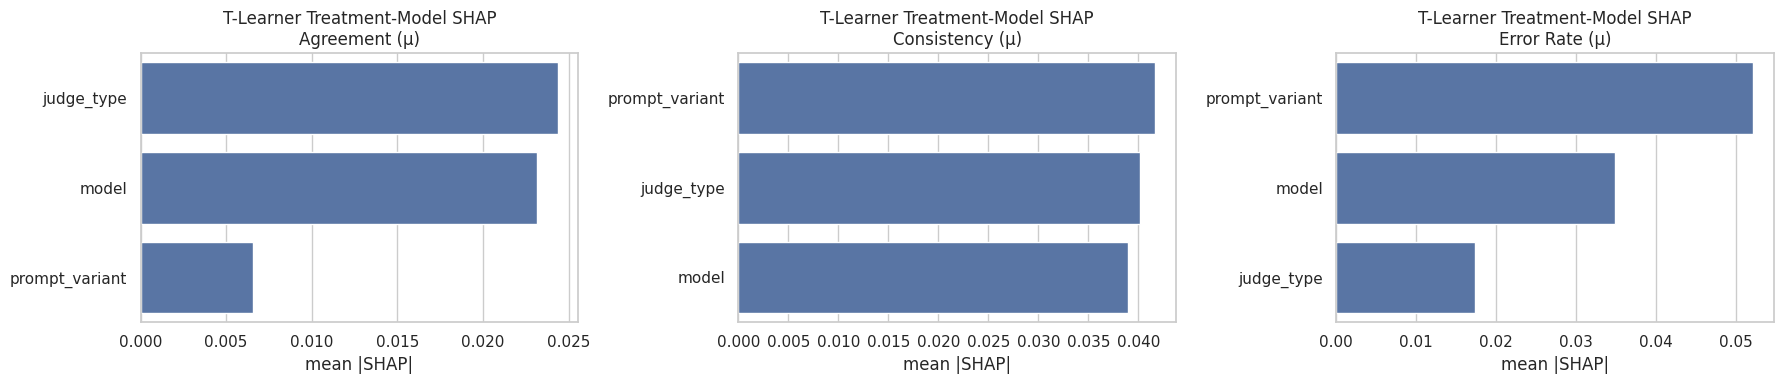

Saved: output/causal_analysis_causalml/tlearner_outcome_shap.png


### Propensity-Model SHAP (GradientBoostedPropensityModel)

Propensity-model SHAP skipped due to explainer incompatibility: could not convert string to float: '[5.002695E-1]'


In [7]:
display(Markdown(
    "## 4. SHAP Feature Attribution on T-Learner\n"
    "SHAP is computed on the T-Learner treatment outcome model to explain what "
    "drives variation in treated-group outcome predictions."
))


def get_tlearner_treatment_model(t_learner):
    treatment_key = t_learner.t_groups[0]
    if hasattr(t_learner, "models_t"):
        return t_learner.models_t[treatment_key]
    if hasattr(t_learner, "models_mu_t"):
        return t_learner.models_mu_t[treatment_key]
    if hasattr(t_learner, "model_t"):
        return t_learner.model_t
    raise AttributeError("Could not find T-Learner treatment outcome model on this CausalML version.")


outcome_shap_df_list = []

for outcome_col in METRIC_COLUMNS:
    print(f"[SHAP] {outcome_col}: accessing T-Learner treatment outcome model...")
    t_learner = meta_results[outcome_col]["T-Learner"]["learner"]
    treatment_model = get_tlearner_treatment_model(t_learner)

    treat_idx = np.where(T_arr == 1)[0]
    sample_size = min(len(treat_idx), 3000)
    sample_idx = np.random.choice(treat_idx, size=sample_size, replace=False)
    X_sample = X_causal.iloc[sample_idx].copy()

    explainer = shap.TreeExplainer(treatment_model)
    explanation = explainer(X_sample)
    sv = np.asarray(explanation.values)
    if sv.ndim == 3:
        sv = sv[:, :, -1]

    abs_shap = pd.DataFrame(np.abs(sv), columns=X_sample.columns)
    grouped = (
        pd.DataFrame({"feature": X_sample.columns, "mean_abs_shap": abs_shap.mean(axis=0).values})
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )
    grouped["Outcome"] = outcome_col
    outcome_shap_df_list.append(grouped)

outcome_shap_df = pd.concat(outcome_shap_df_list, ignore_index=True)
display(outcome_shap_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, outcome_col in zip(axes, METRIC_COLUMNS):
    plot_df = outcome_shap_df[outcome_shap_df["Outcome"] == outcome_col].head(10)
    sns.barplot(data=plot_df, x="mean_abs_shap", y="feature", ax=ax, color="#4c72b0")
    ax.set_title(f"T-Learner Treatment-Model SHAP\n{outcome_col}")
    ax.set_xlabel("mean |SHAP|")
    ax.set_ylabel("")
plt.tight_layout()
shap_bar_path = FIG_DIR / "tlearner_outcome_shap.png"
fig.savefig(shap_bar_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", shap_bar_path)

display(Markdown("### Propensity-Model SHAP (GradientBoostedPropensityModel)"))
prop_inner_model = getattr(ps_model, "model", None) or getattr(ps_model, "model_", None)
if prop_inner_model is not None:
    try:
        sample_ps = X_causal.sample(min(1000, len(X_causal)), random_state=99).copy()
        ps_explainer = shap.TreeExplainer(prop_inner_model)
        ps_explanation = ps_explainer(sample_ps)
        ps_sv = np.asarray(ps_explanation.values)
        if ps_sv.ndim == 3:
            ps_sv = ps_sv[:, :, -1]
        ps_abs = pd.DataFrame(np.abs(ps_sv), columns=sample_ps.columns)
        ps_shap_df = (
            pd.DataFrame({"feature": sample_ps.columns, "mean_abs_shap": ps_abs.mean(axis=0).values})
            .sort_values("mean_abs_shap", ascending=False)
            .reset_index(drop=True)
        )
        display(ps_shap_df)
    except Exception as exc:
        print(f"Propensity-model SHAP skipped due to explainer incompatibility: {exc}")
else:
    print("Could not access propensity model internals — skipping propensity SHAP.")


## 5. Robustness Checks

### 5a. Placebo Permutation Test
Treatment labels are randomly permuted; T-Learner ATE should collapse to ~0.

[Placebo] Agreement (µ): permutation 1/10
[Placebo] Agreement (µ): permutation 2/10
[Placebo] Agreement (µ): permutation 3/10
[Placebo] Agreement (µ): permutation 4/10
[Placebo] Agreement (µ): permutation 5/10
[Placebo] Agreement (µ): permutation 6/10
[Placebo] Agreement (µ): permutation 7/10
[Placebo] Agreement (µ): permutation 8/10
[Placebo] Agreement (µ): permutation 9/10
[Placebo] Agreement (µ): permutation 10/10
[Placebo] Consistency (µ): permutation 1/10
[Placebo] Consistency (µ): permutation 2/10
[Placebo] Consistency (µ): permutation 3/10
[Placebo] Consistency (µ): permutation 4/10
[Placebo] Consistency (µ): permutation 5/10
[Placebo] Consistency (µ): permutation 6/10
[Placebo] Consistency (µ): permutation 7/10
[Placebo] Consistency (µ): permutation 8/10
[Placebo] Consistency (µ): permutation 9/10
[Placebo] Consistency (µ): permutation 10/10
[Placebo] Error Rate (µ): permutation 1/10
[Placebo] Error Rate (µ): permutation 2/10
[Placebo] Error Rate (µ): permutation 3/10
[Placebo]

,Outcome,Observed ATE (T-Learner),Placebo mean,Placebo std,Permutation p-value
0,Agreement (µ),-0.017104,0.000676,0.003631,0.090909
1,Consistency (µ),-0.134215,0.000356,0.001997,0.090909
2,Error Rate (µ),0.050919,0.000185,0.000889,0.090909


Saved: output/causal_analysis_causalml/placebo_permutation_results.csv


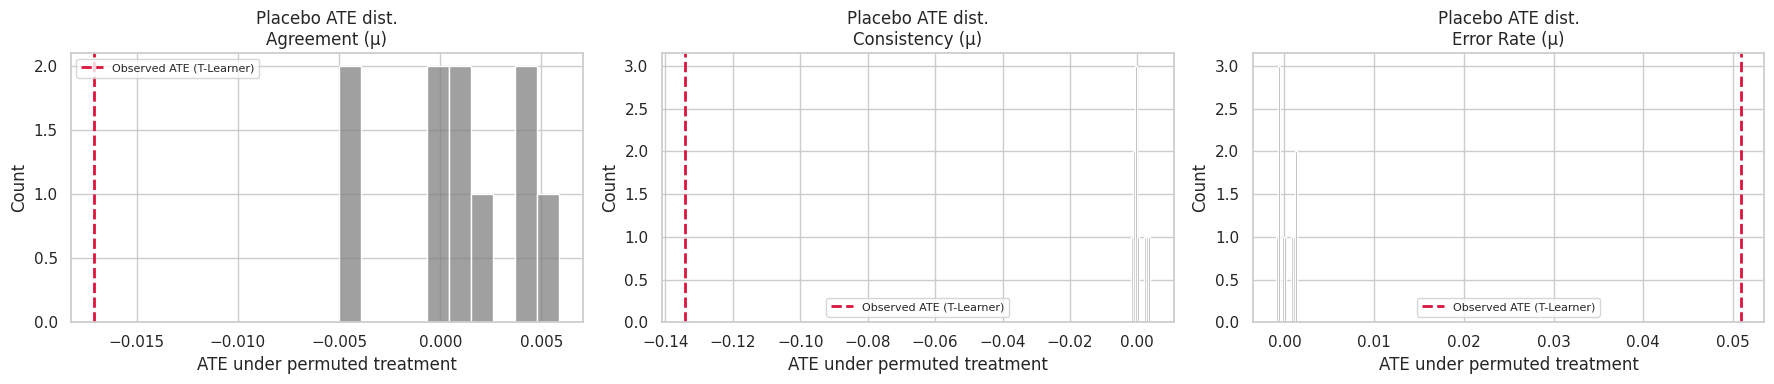

Saved: output/causal_analysis_causalml/placebo_permutation_histograms.png


### 5b. Approximate E-values

,Cohen's d,Approx RR,E-value,Outcome
0,-0.0386,1.0357,1.2281,Agreement (µ)
1,-0.5476,1.6459,2.6770,Consistency (µ)
2,0.4322,1.4819,2.3269,Error Rate (µ)


Saved: output/causal_analysis_causalml/approximate_evalues.csv


### 5c. SHAP Stability
T-Learner treatment outcome models are retrained on bootstrap resamples; grouped SHAP rankings should remain consistent.

[SHAP stability] Agreement (µ): boot 1/8
[SHAP stability] Agreement (µ): boot 2/8
[SHAP stability] Agreement (µ): boot 3/8
[SHAP stability] Agreement (µ): boot 4/8
[SHAP stability] Agreement (µ): boot 5/8
[SHAP stability] Agreement (µ): boot 6/8
[SHAP stability] Agreement (µ): boot 7/8
[SHAP stability] Agreement (µ): boot 8/8
[SHAP stability] Consistency (µ): boot 1/8
[SHAP stability] Consistency (µ): boot 2/8
[SHAP stability] Consistency (µ): boot 3/8
[SHAP stability] Consistency (µ): boot 4/8
[SHAP stability] Consistency (µ): boot 5/8
[SHAP stability] Consistency (µ): boot 6/8
[SHAP stability] Consistency (µ): boot 7/8
[SHAP stability] Consistency (µ): boot 8/8
[SHAP stability] Error Rate (µ): boot 1/8
[SHAP stability] Error Rate (µ): boot 2/8
[SHAP stability] Error Rate (µ): boot 3/8
[SHAP stability] Error Rate (µ): boot 4/8
[SHAP stability] Error Rate (µ): boot 5/8
[SHAP stability] Error Rate (µ): boot 6/8
[SHAP stability] Error Rate (µ): boot 7/8
[SHAP stability] Error Rate (µ): b

,index,Outcome,feature,bootstrap_mean_abs_shap,bootstrap_std_abs_shap
0,0,Agreement (µ),judge_type,0.029729,0.002680
1,1,Agreement (µ),model,0.022769,0.001821
2,2,Agreement (µ),prompt_variant,0.007179,0.001266
3,3,Consistency (µ),judge_type,0.049542,0.001575
4,4,Consistency (µ),model,0.042217,0.001775
5,5,Consistency (µ),prompt_variant,0.042099,0.000855
6,8,Error Rate (µ),prompt_variant,0.052288,0.000801
7,7,Error Rate (µ),model,0.036088,0.000939
8,6,Error Rate (µ),judge_type,0.021339,0.000821


Saved: output/causal_analysis_causalml/shap_stability_summary.csv


In [8]:
display(Markdown("## 5. Robustness Checks"))

# ── 5a. Placebo permutation (T-Learner) ──────────────────────────────────────
display(Markdown(
    "### 5a. Placebo Permutation Test\n"
    "Treatment labels are randomly permuted; T-Learner ATE should collapse to ~0."
))

rng = np.random.default_rng(seed=42)
N_PERM = 10

placebo_results = []
placebo_draw_map = {}

for idx, outcome_col in enumerate(METRIC_COLUMNS):
    Y_arr = analysis_df[outcome_col].to_numpy()
    observed_ate = meta_results[outcome_col]["T-Learner"]["ate"]
    placebo_draws = []

    for perm_i in range(N_PERM):
        print(f"[Placebo] {outcome_col}: permutation {perm_i + 1}/{N_PERM}")
        T_perm = rng.permutation(T_arr)
        t_perm = BaseTLearner(learner=LGBMRegressor(**LGBM_KWARGS), control_name=0)
        te_perm = t_perm.fit_predict(X=X_causal, treatment=T_perm, y=Y_arr, verbose=False)
        placebo_draws.append(float(flatten_cate(te_perm).mean()))

    placebo_draws = np.array(placebo_draws)
    placebo_draw_map[outcome_col] = placebo_draws
    p_value = (np.sum(np.abs(placebo_draws) >= abs(observed_ate)) + 1) / (N_PERM + 1)

    placebo_results.append({
        "Outcome": outcome_col,
        "Observed ATE (T-Learner)": observed_ate,
        "Placebo mean": float(placebo_draws.mean()),
        "Placebo std": float(placebo_draws.std(ddof=1)),
        "Permutation p-value": float(p_value),
    })

placebo_table = pd.DataFrame(placebo_results)
display(placebo_table)
placebo_path = FIG_DIR / "placebo_permutation_results.csv"
placebo_table.to_csv(placebo_path, index=False)
print("Saved:", placebo_path)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, outcome_col in zip(axes, METRIC_COLUMNS):
    sns.histplot(placebo_draw_map[outcome_col], bins=10, color="gray", ax=ax)
    ax.axvline(meta_results[outcome_col]["T-Learner"]["ate"], color="crimson",
               linestyle="--", linewidth=2, label="Observed ATE (T-Learner)")
    ax.set_title(f"Placebo ATE dist.\n{outcome_col}")
    ax.set_xlabel("ATE under permuted treatment")
    ax.legend(fontsize=8)
plt.tight_layout()
placebo_fig_path = FIG_DIR / "placebo_permutation_histograms.png"
fig.savefig(placebo_fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", placebo_fig_path)

# ── 5b. Approximate E-values ──────────────────────────────────────────────────
display(Markdown("### 5b. Approximate E-values"))
evalue_rows = []
for outcome_col in METRIC_COLUMNS:
    ate_val = meta_results[outcome_col]["T-Learner"]["ate"]
    ev = approximate_e_value(analysis_df[outcome_col], ate_val)
    ev["Outcome"] = outcome_col
    evalue_rows.append(ev)

evalue_table = pd.DataFrame(evalue_rows)
display(evalue_table.round(4))
evalue_path = FIG_DIR / "approximate_evalues.csv"
evalue_table.to_csv(evalue_path, index=False)
print("Saved:", evalue_path)

# ── 5c. SHAP stability (bootstrap resampling, T-Learner) ─────────────────────
display(Markdown(
    "### 5c. SHAP Stability\n"
    "T-Learner treatment outcome models are retrained on bootstrap resamples; "
    "grouped SHAP rankings should remain consistent."
))

N_BOOT = 8
stability_frames = []
for outcome_col in METRIC_COLUMNS:
    Y_arr = analysis_df[outcome_col].to_numpy()
    T_mask = T_arr == 1
    X_treat = X_causal[T_mask].reset_index(drop=True)
    Y_treat = Y_arr[T_mask]

    for boot_idx in range(N_BOOT):
        print(f"[SHAP stability] {outcome_col}: boot {boot_idx + 1}/{N_BOOT}")
        boot_idx_arr = rng.integers(0, len(X_treat), size=len(X_treat))
        X_boot, Y_boot = X_treat.iloc[boot_idx_arr], Y_treat[boot_idx_arr]
        m = LGBMRegressor(**{**LGBM_KWARGS, "random_state": 100 + boot_idx})
        m.set_params(n_estimators=150)
        m.fit(X_boot, Y_boot)
        grouped, _ = grouped_shap_importance(m, X_boot, max_rows=2000, random_state=42)
        grouped["bootstrap"] = boot_idx
        grouped["Outcome"] = outcome_col
        stability_frames.append(grouped)

stability_df = pd.concat(stability_frames, ignore_index=True)
stability_summary = (
    stability_df.groupby(["Outcome", "feature"], as_index=False)["mean_abs_shap"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={"mean": "bootstrap_mean_abs_shap", "std": "bootstrap_std_abs_shap"})
    .sort_values(["Outcome", "bootstrap_mean_abs_shap"], ascending=[True, False])
    .reset_index(drop=True)
)
display(stability_summary)
stability_path = FIG_DIR / "shap_stability_summary.csv"
stability_summary.to_csv(stability_path, index=False)
print("Saved:", stability_path)


In [9]:
display(Markdown(
    "## 6. Discussion\n"
    "Automated summary drawing from all CausalML estimators."
))

discussion_rows = []
for outcome_col in METRIC_COLUMNS:
    # Use T-Learner as the reference ATE (most interpretable for our balanced setting)
    ate_value = meta_results[outcome_col]["T-Learner"]["ate"]
    direction = "increases" if ate_value >= 0 else "decreases"

    # Top SHAP feature from T-learner (built in SHAP cell above)
    shap_row = outcome_shap_df[outcome_shap_df["Outcome"] == outcome_col]
    top_driver = shap_row.iloc[0]["feature"] if len(shap_row) > 0 else "N/A"

    # Best model moderator by CATE magnitude from CausalTree subgroup
    mod_rows = subgroup_cate_df[
        (subgroup_cate_df["Outcome"] == outcome_col) &
        (subgroup_cate_df["Moderator"] == "model")
    ]
    top_model = (
        mod_rows.sort_values("Mean CATE (CausalTree)", key=lambda s: s.abs(), ascending=False)
        .iloc[0]["Level"]
        if len(mod_rows) > 0 else "N/A"
    )

    placebo_p = float(
        placebo_table.loc[placebo_table["Outcome"] == outcome_col, "Permutation p-value"].iloc[0]
    )
    ev = float(evalue_table.loc[evalue_table["Outcome"] == outcome_col, "E-value"].iloc[0])
    auuc_val = float(auuc_df.loc[auuc_df["Outcome"] == outcome_col, "AUUC (T-Learner)"].iloc[0])

    discussion_rows.append({
        "Outcome": outcome_col,
        "ATE interpretation (T-Learner)": (
            f"Moving to high temperature {direction} {outcome_col} by {ate_value:.4f} on average."
        ),
        "Top SHAP driver": top_driver,
        "Strongest model moderator": top_model,
        "Permutation p-value": placebo_p,
        "Approx E-value": ev,
        "AUUC (T-Learner)": auuc_val,
    })

discussion_table = pd.DataFrame(discussion_rows)
display(discussion_table)
disc_path = FIG_DIR / "discussion_summary.csv"
discussion_table.to_csv(disc_path, index=False)
print("Saved:", disc_path)

summary_lines = ["## Automatically generated discussion"]
for row in discussion_table.itertuples(index=False):
    learner_ates = {m: f"{meta_results[row.Outcome][m]['ate']:.4f}" for m in LEARNER_FACTORIES}
    ate_str = ", ".join(f"{m}: {v}" for m, v in learner_ates.items())
    summary_lines.append(
        f"- **{row.Outcome}**: {row[1]} "
        f"All-learner ATEs — {ate_str}. "
        f"Top T-Learner SHAP driver: `{row[2]}`. "
        f"Strongest model moderator (CausalTree): `{row[3]}`. "
        f"Placebo p = {row[4]:.4f}; approx E-value = {row[5]:.4f}; AUUC = {row[6]:.4f}."
    )
display(Markdown("\n".join(summary_lines)))


## 6. Discussion
Automated summary drawing from all CausalML estimators.

,Outcome,ATE interpretation (T-Learner),Top SHAP driver,Strongest model moderator,Permutation p-value,Approx E-value,AUUC (T-Learner)
0,Agreement (µ),Moving to high temperature decreases Agreement...,judge_type,Qwen3-Next-80B-A3B-Instruct-FP8,0.090909,1.228138,-0.162830
1,Consistency (µ),Moving to high temperature decreases Consisten...,prompt_variant,Qwen3-30B-A3B-Instruct-2507,0.090909,2.676996,-0.424668
2,Error Rate (µ),Moving to high temperature increases Error Rat...,prompt_variant,Qwen3-Next-80B-A3B-Instruct-FP8,0.090909,2.326855,0.786583


Saved: output/causal_analysis_causalml/discussion_summary.csv


## Automatically generated discussion
- **Agreement (µ)**: Moving to high temperature decreases Agreement (µ) by -0.0171 on average. All-learner ATEs — S-Learner: -0.0166, T-Learner: -0.0171, X-Learner: -0.0172, R-Learner: -0.0171, DR-Learner: -0.0171. Top T-Learner SHAP driver: `judge_type`. Strongest model moderator (CausalTree): `Qwen3-Next-80B-A3B-Instruct-FP8`. Placebo p = 0.0909; approx E-value = 1.2281; AUUC = -0.1628.
- **Consistency (µ)**: Moving to high temperature decreases Consistency (µ) by -0.1342 on average. All-learner ATEs — S-Learner: -0.1305, T-Learner: -0.1342, X-Learner: -0.1342, R-Learner: -0.1343, DR-Learner: -0.1342. Top T-Learner SHAP driver: `prompt_variant`. Strongest model moderator (CausalTree): `Qwen3-30B-A3B-Instruct-2507`. Placebo p = 0.0909; approx E-value = 2.6770; AUUC = -0.4247.
- **Error Rate (µ)**: Moving to high temperature increases Error Rate (µ) by 0.0509 on average. All-learner ATEs — S-Learner: 0.0495, T-Learner: 0.0509, X-Learner: 0.0509, R-Learner: 0.0509, DR-Learner: 0.0509. Top T-Learner SHAP driver: `prompt_variant`. Strongest model moderator (CausalTree): `Qwen3-Next-80B-A3B-Instruct-FP8`. Placebo p = 0.0909; approx E-value = 2.3269; AUUC = 0.7866.

## Extra: SHAP Beeswarm (T-Learner Treatment Outcome Model)

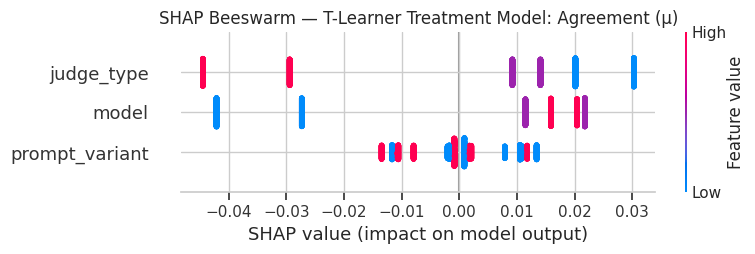

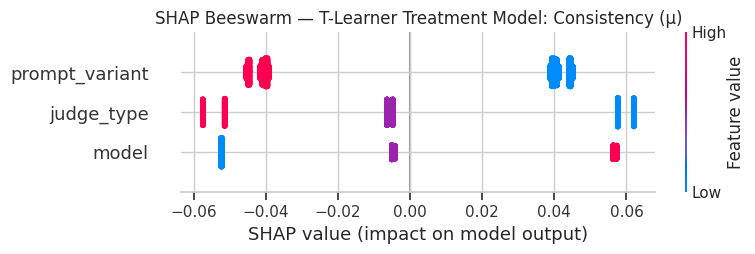

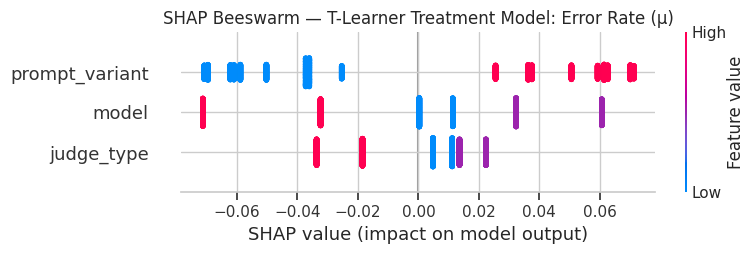

Saved beeswarm plots:
- output/causal_analysis_causalml/tlearner_shap_beeswarm_Agreement_mu.png
- output/causal_analysis_causalml/tlearner_shap_beeswarm_Consistency_mu.png
- output/causal_analysis_causalml/tlearner_shap_beeswarm_Error_Rate_mu.png


In [10]:
display(Markdown("## Extra: SHAP Beeswarm (T-Learner Treatment Outcome Model)"))

beeswarm_paths = []

for outcome_col in METRIC_COLUMNS:
    t_learner = meta_results[outcome_col]["T-Learner"]["learner"]
    treatment_model = get_tlearner_treatment_model(t_learner)

    treat_idx = np.where(T_arr == 1)[0]
    sample_size = min(len(treat_idx), 3000)
    sample_idx_arr = np.random.RandomState(2026).choice(treat_idx, size=sample_size, replace=False)
    X_sample = X_causal.iloc[sample_idx_arr].copy()

    explainer = shap.TreeExplainer(treatment_model)
    explanation = explainer(X_sample)
    values = np.asarray(explanation.values)
    base_values = np.asarray(explanation.base_values)
    if values.ndim == 3:
        values = values[:, :, -1]

    beeswarm_exp = shap.Explanation(
        values=values,
        base_values=base_values,
        data=X_sample.to_numpy(),
        feature_names=list(X_sample.columns),
    )

    plt.figure(figsize=(8, 5))
    shap.plots.beeswarm(beeswarm_exp, max_display=12, show=False)
    plt.title(f"SHAP Beeswarm — T-Learner Treatment Model: {outcome_col}")
    plt.tight_layout()

    safe_name = (
        outcome_col
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("µ", "mu")
        .replace("/", "_")
    )
    beeswarm_path = FIG_DIR / f"tlearner_shap_beeswarm_{safe_name}.png"
    plt.savefig(beeswarm_path, dpi=220, bbox_inches="tight")
    plt.show()
    beeswarm_paths.append(beeswarm_path)

print("Saved beeswarm plots:")
for p in beeswarm_paths:
    print("-", p)
